We decided to work with CIFAR-10 for the Project.
1. load data
- Load training and test sets
- Verify shapes
- Verify data types
- Verify labels
2. EDA:
  - print dataset shape & pixel range
  - print classes (class imbalance)
  - check for duplicates
  - check for blanks
  - Visualization:
    - random (32 images)
    - random images per class
3. Data Preprocessing
  - Normalizing values
  - One-hot encoding (to_categorical())
  - Split the data
    Training set
    Validation set
    Test set
    Use stratification if appropriate ?
  - Data augmentation
    Examples:
    Horizontal flip
    Small rotations
    Zoom
    Width/height shifts
    (Apply only to the training set.)
 4. Build a CNN from Scratch

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

In [3]:
x_temp = np.load('/content/drive/MyDrive/cifar10_data/x_train.npy')
y_temp = np.load('/content/drive/MyDrive/cifar10_data/y_train.npy')
x_test = np.load('/content/drive/MyDrive/cifar10_data/x_test.npy')
y_test = np.load('/content/drive/MyDrive/cifar10_data/y_test.npy')

In [4]:
import tensorflow as tf

x_temp = tf.image.resize(x_temp, [32, 32]).numpy()
x_test  = tf.image.resize(x_test,  [32, 32]).numpy()

np.save('/content/drive/MyDrive/cifar10_data/x_train.npy', x_temp)
np.save('/content/drive/MyDrive/cifar10_data/x_test.npy',  x_test)

print("Done! Shapes:")
print("x_train:", x_temp.shape)
print("x_test: ", x_test.shape)

Done! Shapes:
x_train: (50000, 32, 32, 3)
x_test:  (10000, 32, 32, 3)


In [ ]:
print("x_temp:", x_temp.shape)
print("y_temp:", y_temp.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

x_temp: (50000, 32, 32, 3)
y_temp: (50000, 10)
x_test : (10000, 32, 32, 3)
y_test : (10000, 10)


In [6]:
import numpy as np

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
labels, counts = np.unique(np.argmax(y_temp, axis=1), return_counts=True)

for l, c in zip(labels, counts):
    print(f"{classes[int(l)]}: {c}")

airplane: 5000
automobile: 5000
bird: 5000
cat: 5000
deer: 5000
dog: 5000
frog: 5000
horse: 5000
ship: 5000
truck: 5000


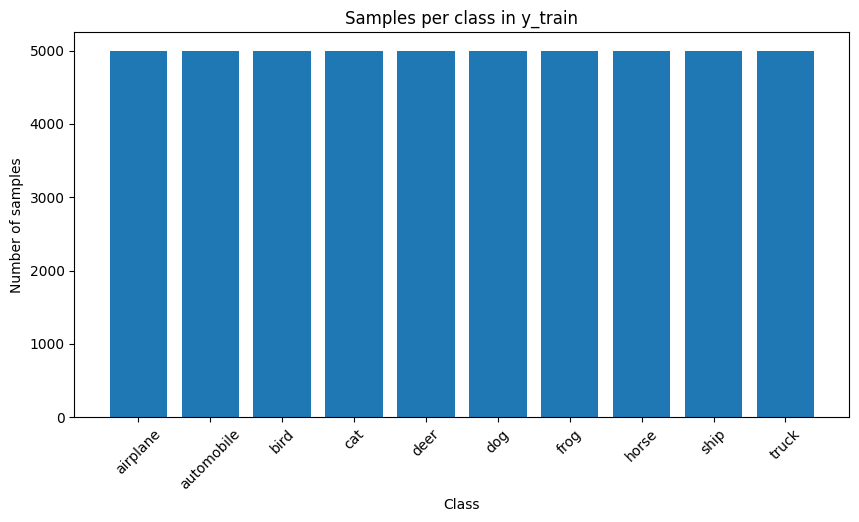

In [7]:
import matplotlib.pyplot as plt

labels, counts = np.unique(np.argmax(y_temp, axis=1), return_counts=True)

plt.figure(figsize=(10,5))
plt.bar([classes[int(l)] for l in labels], counts)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Samples per class in y_train")
plt.xticks(rotation=45)
plt.show()

In [8]:
# Basic info & pixel range
print("=== Dataset shapes ===")
print(f"x_temp: {x_temp.shape}")
print(f"y_temp: {y_temp.shape}")
print(f"x_test:  {x_test.shape}")
print(f"y_test:  {y_test.shape}")

print("\n=== Pixel values ===")
print(f"Min: {x_temp.min()}")
print(f"Max: {x_temp.max()}")
print(f"Mean: {x_temp.mean():.4f}")

=== Dataset shapes ===
x_temp: (50000, 32, 32, 3)
y_temp: (50000, 10)
x_test:  (10000, 32, 32, 3)
y_test:  (10000, 10)

=== Pixel values ===
Min: 0.0
Max: 1.0
Mean: 0.4734


In [9]:
# Duplicates?

# x_flat = x_temp.reshape(len(x_temp), -1)
# unique = np.unique(x_flat, axis=0)
# print(f"Total images:  {len(x_temp)}")
# print(f"Unique images: {len(unique)}")
# print(f"Duplicates:    {len(x_temp) - len(unique)}")


In [10]:
# blank images? if all pixels same value -> is blank

# blank = [i for i in range(len(x_temp)) if x_temp[i].std() == 0]
# print(f"Blank/corrupt images: {len(blank)}")

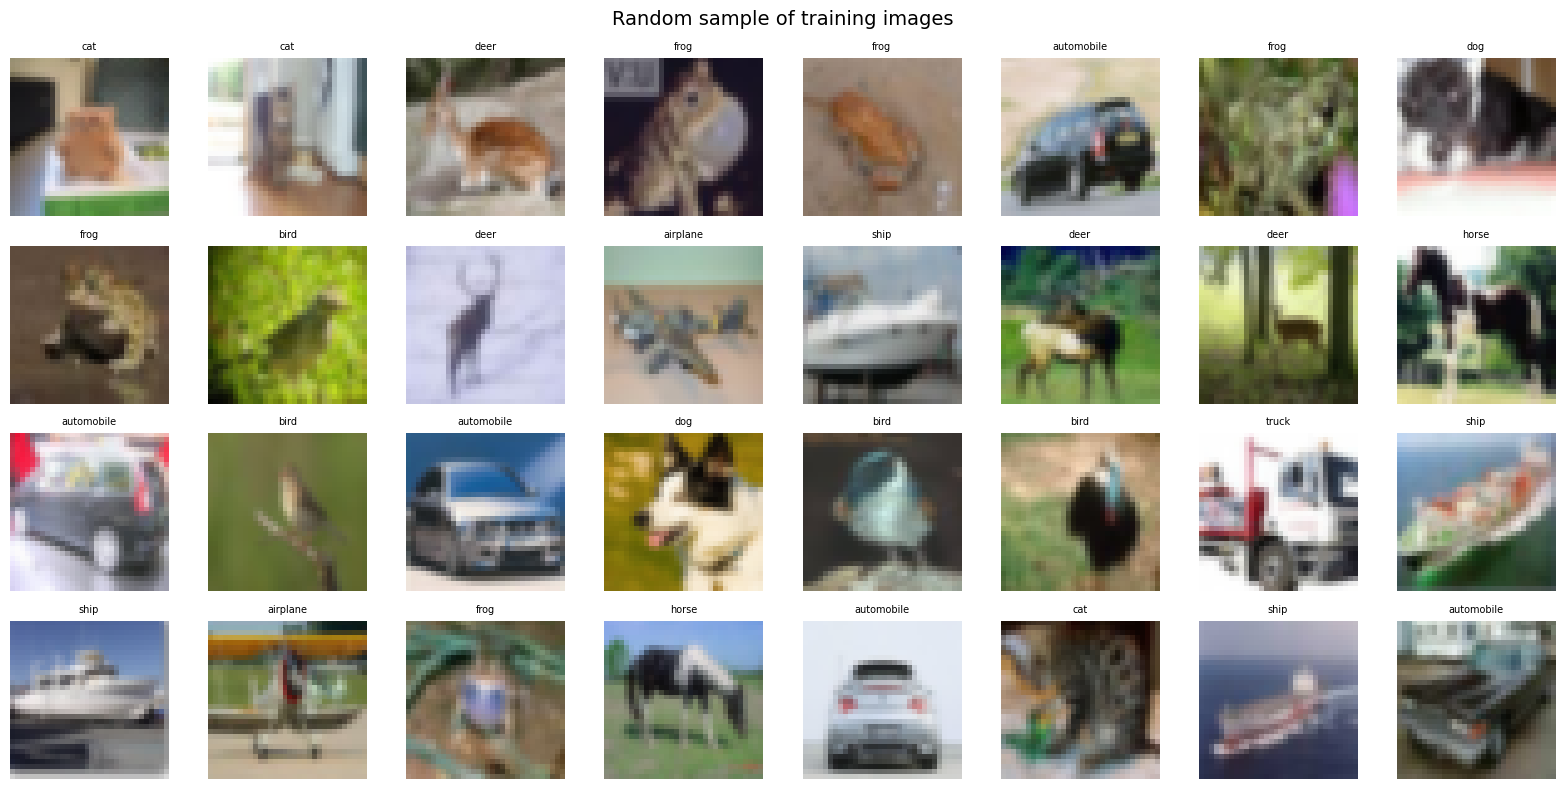

In [11]:
# random plot of images

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.flatten()

random_indices = np.random.choice(len(x_temp), 32, replace=False)

for i, idx in enumerate(random_indices):
    axes[i].imshow(x_temp[idx])
    axes[i].set_title(classes[np.argmax(y_temp[idx])], fontsize=7)
    axes[i].axis('off')

plt.suptitle('Random sample of training images', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print(y_temp.shape)
print(y_temp[0])

(50000, 10)
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


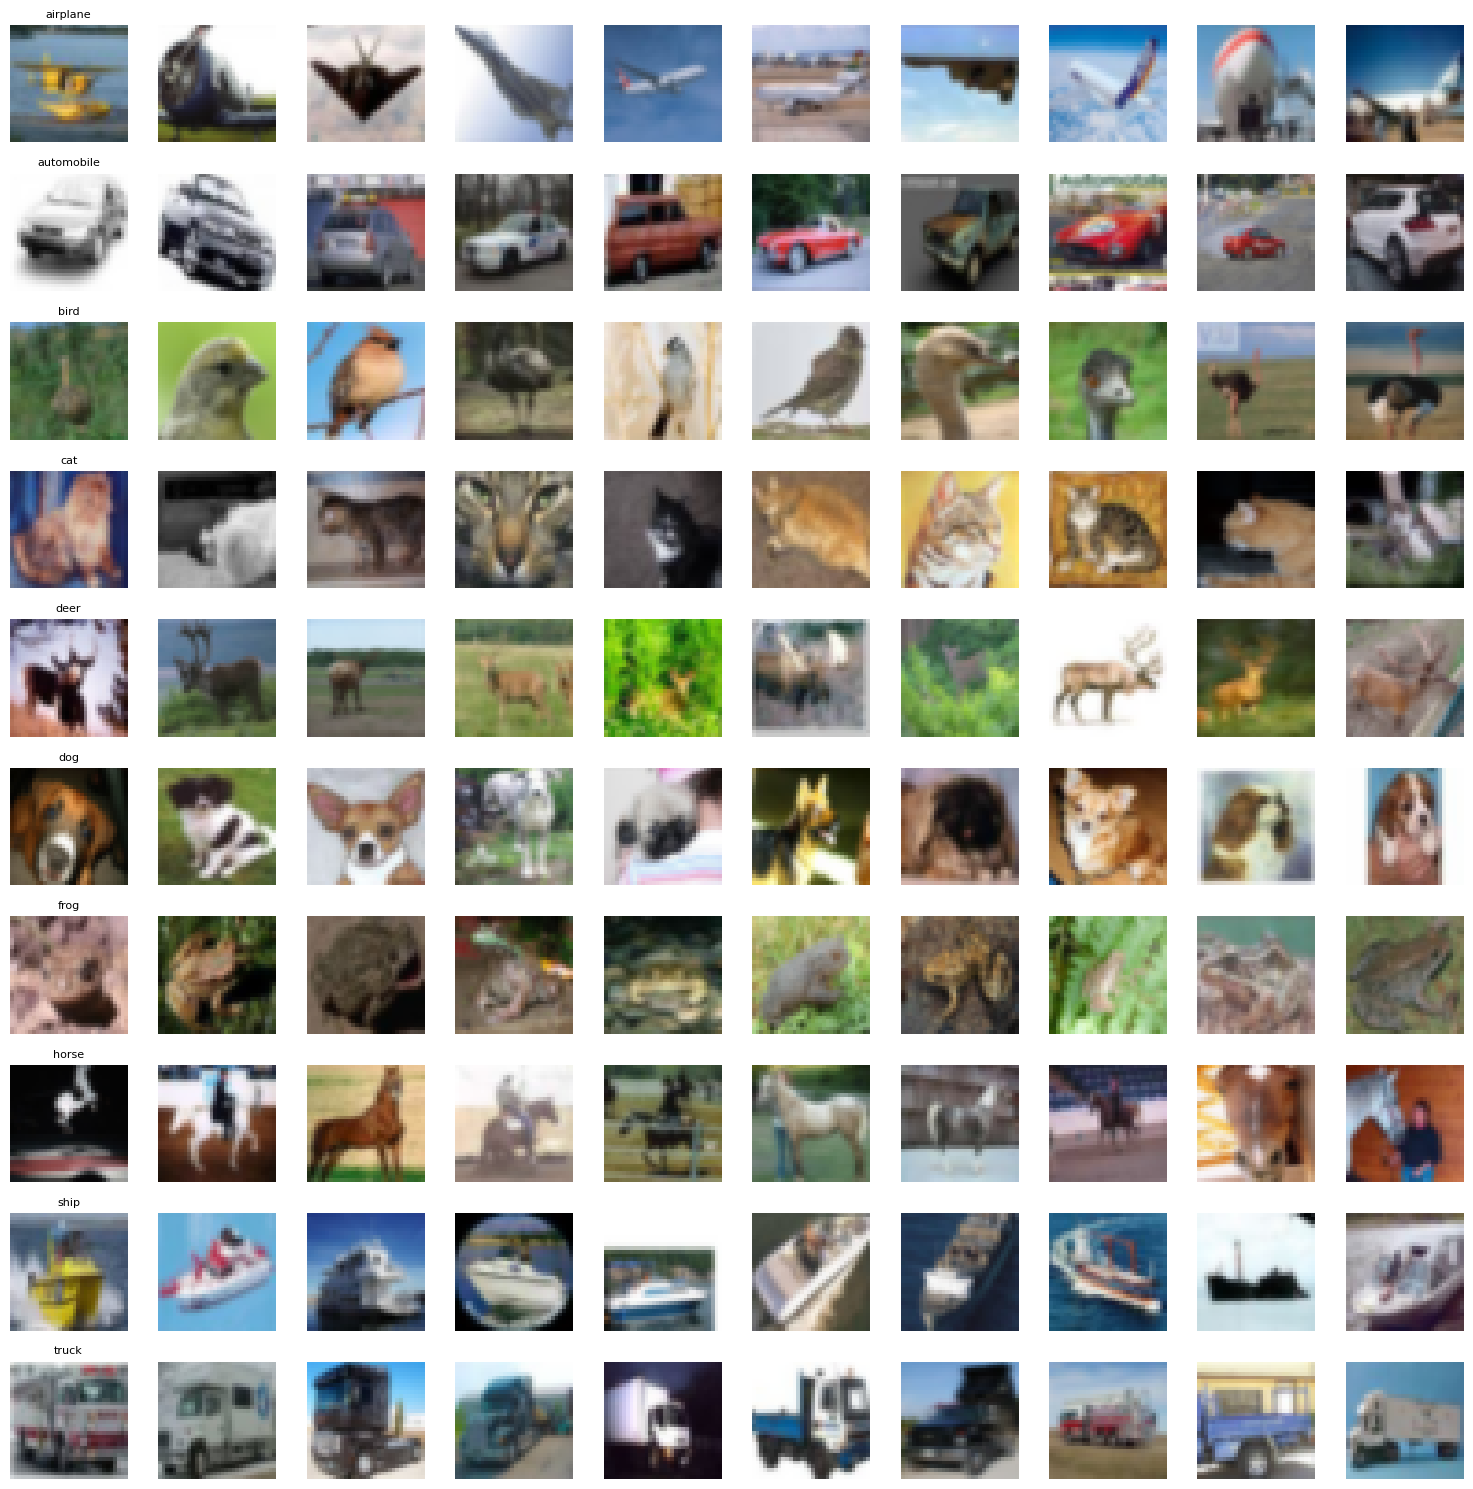

In [13]:
# Visualise samples/class

fig, axes = plt.subplots(10, 10, figsize=(15, 15))

y_temp_labels = np.argmax(y_temp, axis=1)  # recover integer labels

for class_idx in range(10):
    class_indices = np.where(y_temp_labels == class_idx)[0]
    sample_indices = np.random.choice(class_indices, 10, replace=False)
    for col, img_idx in enumerate(sample_indices):
        axes[class_idx, col].imshow(x_temp[img_idx])
        axes[class_idx, col].axis('off')
        if col == 0:
            axes[class_idx, col].set_title(classes[class_idx], fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split

# x_train, y_train from CIFAR-10's original train set
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.18,
    stratify=y_temp.argmax(axis=1),    # keep class balance
    random_state=42
)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val  :", x_val.shape)
print("y_val  :", y_val.shape)

x_train: (41000, 32, 32, 3)
y_train: (41000, 10)
x_val  : (9000, 32, 32, 3)
y_val  : (9000, 10)


# Resize to 96x96 & Apply MobileNetV2 Preprocessing

In [15]:
import tensorflow as tf

x_train_96 = tf.image.resize(x_train, [96, 96]).numpy()
x_val_96   = tf.image.resize(x_val,   [96, 96]).numpy()
x_test_96  = tf.image.resize(x_test,  [96, 96]).numpy()

print("x_train_96:", x_train_96.shape)
print("x_val_96:  ", x_val_96.shape)
print("x_test_96: ", x_test_96.shape)

x_train_96: (41000, 96, 96, 3)
x_val_96:   (9000, 96, 96, 3)
x_test_96:  (10000, 96, 96, 3)


In [16]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

x_train_mob = preprocess_input(x_train_96 * 255.0)
x_val_mob   = preprocess_input(x_val_96   * 255.0)
x_test_mob  = preprocess_input(x_test_96  * 255.0)

print("Pixel range after preprocessing:")
print(f"Min: {x_train_mob.min():.2f}")
print(f"Max: {x_train_mob.max():.2f}")

Pixel range after preprocessing:
Min: -1.00
Max: 1.00


# Build Model - Frozen Base

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input


base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  


inputs = Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)

model_mob = Model(inputs, outputs)
model_mob.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,754 (9.25 MB)

 Trainable params: 165,514 (646.54 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

# Phase 1 - train Head Only

In [18]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import time

model_mob.compile(
    optimizer=Adam(learning_rate=0.001),  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop   = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
checkpoint   = ModelCheckpoint(
    '/content/drive/MyDrive/cifar10_data/best_mobilenet_phase1.keras',
    monitor='val_loss', save_best_only=True, verbose=1
)

start = time.time()

history_phase1 = model_mob.fit(
    x_train_mob, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_val_mob, y_val),
    callbacks=[early_stop, lr_scheduler, checkpoint]
)

end = time.time()
print(f"\nPhase 1 training time: {(end - start)/60:.1f} minutes")
print(f"Stopped at epoch: {len(history_phase1.history['accuracy'])}")
print(f"Final train accuracy:      {history_phase1.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_phase1.history['val_accuracy'][-1]:.4f}")

Epoch 1/20
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7022 - loss: 0.9082
Epoch 1: val_loss improved from None to 0.55578, saving model to /content/drive/MyDrive/cifar10_data/best_mobilenet_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cifar10_data/best_mobilenet_phase1.keras
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 49s 25ms/step - accuracy: 0.7525 - loss: 0.7349 - val_accuracy: 0.8114 - val_loss: 0.5558 - learning_rate: 0.0010
Epoch 2/20
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7986 - loss: 0.5845
Epoch 2: val_loss did not improve from 0.55578
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7999 - loss: 0.5823 - val_accuracy: 0.8038 - val_loss: 0.5669 - learning_rate: 0.0010
Epoch 3/20
1277/1282 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8143 - loss: 0.5389
Epoch 3: val_loss improved from 0.55578 to 0.55365, saving model to /content/drive/MyDrive/cifar10_data/best_mobilenet_phase1.keras

Epoch 3: finished saving model to /co

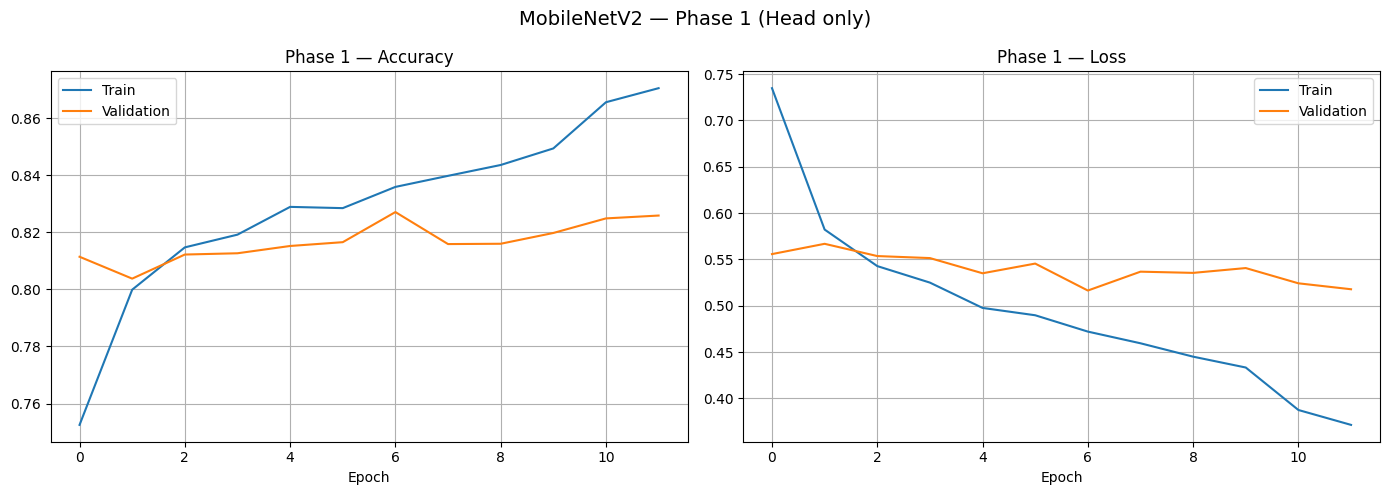

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_phase1.history['accuracy'],     label='Train')
ax1.plot(history_phase1.history['val_accuracy'], label='Validation')
ax1.set_title('Phase 1 — Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history_phase1.history['loss'],     label='Train')
ax2.plot(history_phase1.history['val_loss'], label='Validation')
ax2.set_title('Phase 1 — Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.suptitle('MobileNetV2 — Phase 1 (Head only)', fontsize=14)
plt.tight_layout()
plt.show()

# Phase 2 - Fine-tune Top Layers

In [20]:

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum([tf.size(w).numpy() for w in model_mob.trainable_weights])
print(f"Trainable params after unfreezing: {trainable_count:,}")


model_mob.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop2  = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
checkpoint2  = ModelCheckpoint(
    '/content/drive/MyDrive/cifar10_data/best_mobilenet_phase2.keras',
    monitor='val_loss', save_best_only=True, verbose=1
)

start = time.time()

history_phase2 = model_mob.fit(
    x_train_mob, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(x_val_mob, y_val),
    callbacks=[early_stop2, lr_scheduler2, checkpoint2]
)

end = time.time()
print(f"\nPhase 2 training time: {(end - start)/60:.1f} minutes")
print(f"Stopped at epoch: {len(history_phase2.history['accuracy'])}")
print(f"Final train accuracy:      {history_phase2.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history_phase2.history['val_accuracy'][-1]:.4f}")

Trainable params after unfreezing: 1,691,914
Epoch 1/20
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7294 - loss: 0.8409
Epoch 1: val_loss improved from None to 0.53715, saving model to /content/drive/MyDrive/cifar10_data/best_mobilenet_phase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cifar10_data/best_mobilenet_phase2.keras
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.7567 - loss: 0.7446 - val_accuracy: 0.8189 - val_loss: 0.5372 - learning_rate: 1.0000e-05
Epoch 2/20
1279/1282 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8086 - loss: 0.5738
Epoch 2: val_loss improved from 0.53715 to 0.49969, saving model to /content/drive/MyDrive/cifar10_data/best_mobilenet_phase2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cifar10_data/best_mobilenet_phase2.keras
1282/1282 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.8117 - loss: 0.5592 - val_accuracy: 0.8293 - val_loss: 0.4997 - learning_rate: 1.0000e-05
Epoch 3/20
1281/1282

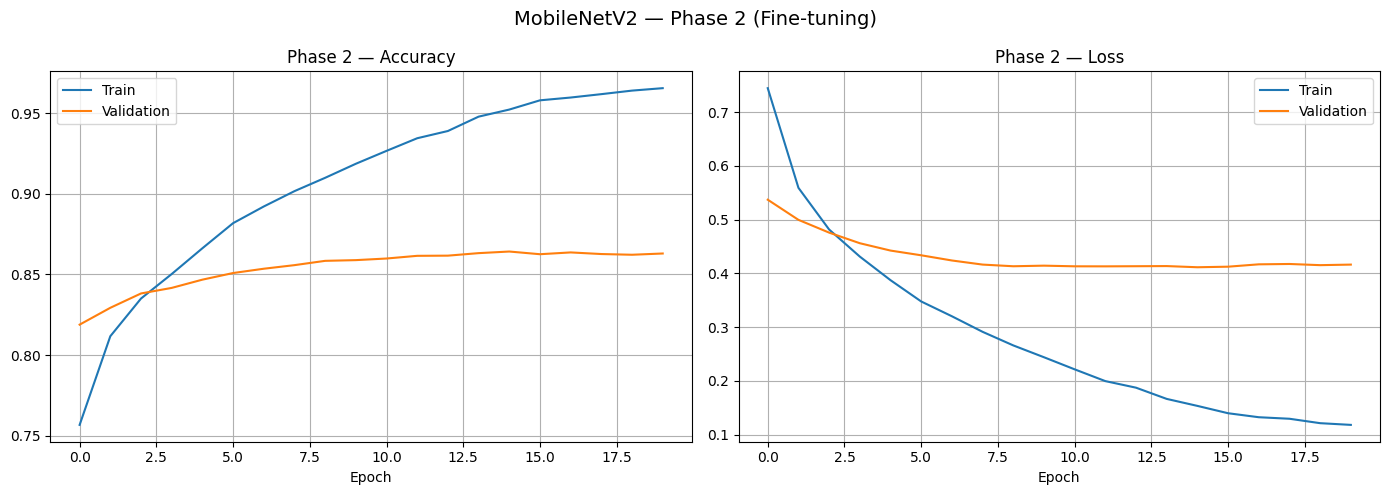

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_phase2.history['accuracy'],     label='Train')
ax1.plot(history_phase2.history['val_accuracy'], label='Validation')
ax1.set_title('Phase 2 — Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history_phase2.history['loss'],     label='Train')
ax2.plot(history_phase2.history['val_loss'], label='Validation')
ax2.set_title('Phase 2 — Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.suptitle('MobileNetV2 — Phase 2 (Fine-tuning)', fontsize=14)
plt.tight_layout()
plt.show()

In [23]:
model.save("Model_cf_10.keras")

NameError: name 'model' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/Model_cf_10.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
